# Activity: Statistical Inference with Palmer Penguins
**Objective:** Apply Confidence Intervals, T-Tests, and Z-Tests to real-world biological data to make data-driven claims about penguin populations.

## Data Packages:
 - **seaborn:** For data loading and visualization.
 - **scipy.stats:** For Confidence Intervals and T-Tests.
 - **statsmodels:** For the Z-test of proportions.


### Import packages

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as st
from statsmodels.stats.proportion import proportions_ztest


 ### Load data

In [2]:
df = sns.load_dataset('penguins').dropna()
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


### Task 1: Confidence Intervals (The Weight of a Species )
Estimate the true population mean weight of each species of penguins.


In [4]:
data_mass = df['body_mass_g']
mean_mass = np.mean(data_mass)
sem_mass = st.sem(data_mass) #sem is standard error
ci_lower, ci_upper = st.t.interval(confidence=0.95, df=len(data_mass)-1, loc=mean_mass, scale=sem_mass) 
#standard deviation not known, so using t, df here is degree of freedom
print(f"Average weight of all penguins is: {mean_mass:.2f} ")
print(f"95% Confidenc Interval for average weight of all penguin is ( {ci_lower:.2f}, {ci_upper:.2f})  ")

Average weight of all penguins is: 4207.06 
95% Confidenc Interval for average weight of all penguin is ( 4120.26, 4293.86)  


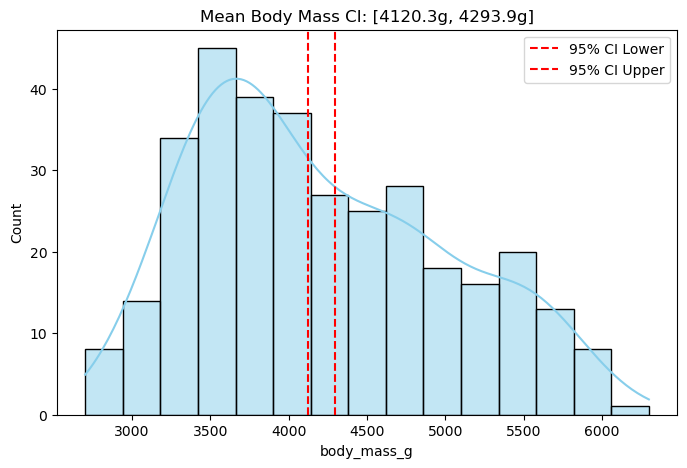

In [5]:
plt.figure(figsize=(8, 5))

#Body Mass Distribution of all sample penguins with Confidence Interval
sns.histplot(df['body_mass_g'], bins=15, kde=True, color='skyblue') #the smooth line is from kde = true
plt.axvline(ci_lower, color='red', linestyle='--', label='95% CI Lower') # these are the vertical lines for CI
plt.axvline(ci_upper, color='red', linestyle='--', label='95% CI Upper')
plt.title(f'Mean Body Mass CI: [{ci_lower:.1f}g, {ci_upper:.1f}g]')
plt.legend()
plt.show()

In [7]:
species= df['species'].unique()

for s in species:
    # Filter data for the specific species
    species_data = df[df['species'] == s]['body_mass_g']
    
    # Calculate stats
    n = len(species_data)
    mean_mass = np.mean(species_data)
    sem = st.sem(species_data) # Standard Error
    
    # Calculate 95% CI
    ci_lower, ci_upper = st.t.interval(confidence=0.95, df=n-1, loc=mean_mass, scale=sem)
    print(f"Average weight of {s} penguins is: {mean_mass:.2f} ")
    print(f"95% Confidenc Interval for average weight of {s} penguins is ( {ci_lower:.2f}, {ci_upper:.2f}) \n ")
    

Average weight of Adelie penguins is: 3706.16 
95% Confidenc Interval for average weight of Adelie penguins is ( 3631.15, 3781.18) 
 
Average weight of Chinstrap penguins is: 3733.09 
95% Confidenc Interval for average weight of Chinstrap penguins is ( 3640.06, 3826.12) 
 
Average weight of Gentoo penguins is: 5092.44 
95% Confidenc Interval for average weight of Gentoo penguins is ( 5001.40, 5183.47) 
 


C:\Users\black\AppData\Local\Temp\ipykernel_24044\1150363785.py:3: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(x='species', y='body_mass_g', data=df, errorbar=('ci', 95), join= False, capsize=0.1)


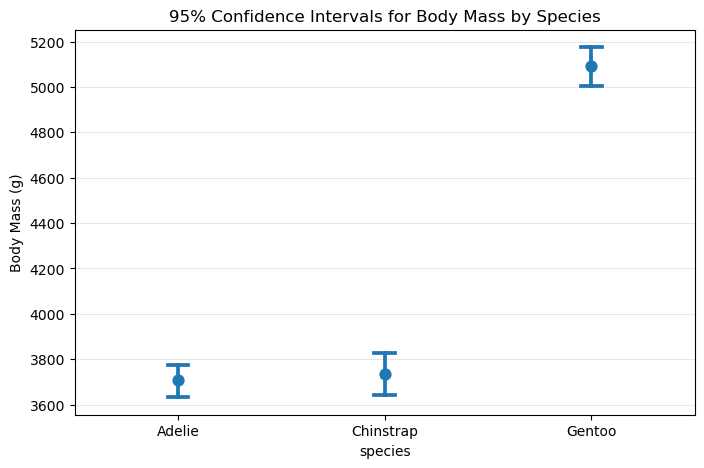

In [10]:
plt.figure(figsize=(8, 5))
#point plot just shows mean and errorerrors
sns.pointplot(x='species', y='body_mass_g', data=df, errorbar=('ci', 95), join= False, capsize=0.1)
#sns.barplot(x='species', y='body_mass_g', data=df, errorbar=('ci', 95), capsize=0.1)
# can also add the error bar to the barplot
plt.title('95% Confidence Intervals for Body Mass by Species')
plt.ylabel('Body Mass (g)')
plt.grid(axis='y', alpha=0.3)
plt.show()

## Hypothesis Testing: T-TEST (COMPARING MEANS) 
### Task: Compare the flipper length of Adelie vs. Gentoo penguins.
### H0: No significant difference in flipper length.

In [11]:
adelie_flipper = df[df['species'] == 'Adelie']['flipper_length_mm']
gentoo_flipper = df[df['species'] == 'Gentoo']['flipper_length_mm']

t_stat, t_pval = st.ttest_ind(adelie_flipper, gentoo_flipper) # _ind is two sample, independent t test

print("--- Independent T-Test ---")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {t_pval:.4f}")
if t_pval < 0.05:
    print("Decision: Reject H0 (Significant difference found)\n")
    if np.mean(adelie_flipper) > np.mean(gentoo_flipper):
        print (f"Adelie flipper (mean = {np.mean(adelie_flipper):.2f}) is bigger than Gentoo flipper (mean = {np.mean(gentoo_flipper):.2f}) ")
    else:
        print (f"Gentoo flipper (mean = {np.mean(gentoo_flipper):.2f}) is bigger than Adelie flipper (mean = {np.mean(adelie_flipper):.2f}) ")
else:
    print("Decision: Fail to reject H0\n")

--- Independent T-Test ---
T-statistic: -33.5388
P-value: 0.0000
Decision: Reject H0 (Significant difference found)

Gentoo flipper (mean = 217.24) is bigger than Adelie flipper (mean = 190.10) 


C:\Users\black\AppData\Local\Temp\ipykernel_24044\2486179341.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='species', y='flipper_length_mm', data=df[df['species'].isin(['Adelie', 'Gentoo'])], palette='Set2')


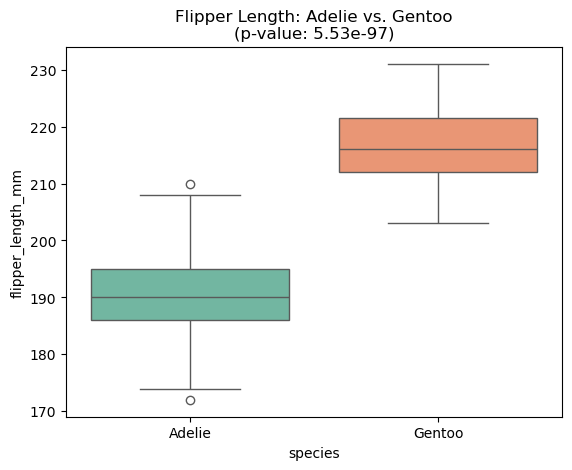

In [12]:
sns.boxplot(x='species', y='flipper_length_mm', data=df[df['species'].isin(['Adelie', 'Gentoo'])], palette='Set2')
plt.title(f'Flipper Length: Adelie vs. Gentoo\n(p-value: {t_pval:.2e})')
plt.show()

## Hypothesis Testing: Z-TEST (Test of Proportion)

### Task: Is the proportion of Biscoe Island penguins significantly different from 33% (0.33)?
### H0: Proportion = 0.33

In [13]:
count_biscoe = len(df[df['island'] == 'Biscoe'])
n_total = len(df)
null_prop = 0.33

z_stat, z_pval = proportions_ztest(count=count_biscoe, nobs=n_total, value=null_prop)

print("Z-Test of Proportion ---")
print(f"Sample Proportion: {count_biscoe/n_total:.3f}")
print(f"Z-statistic: {z_stat:.3f}")
print(f"P-value: {z_pval:.3f}")
if z_pval < 0.05:
    print("Decision: Reject H0")
    print(f"Proportion of Biscoe Island penguins is significantly different from {null_prop*100}%")
    
else:
    print("Decision: Fail to reject H0")

Z-Test of Proportion ---
Sample Proportion: 0.489
Z-statistic: 5.822
P-value: 0.000
Decision: Reject H0
Proportion of Biscoe Island penguins is significantly different from 33.0%


C:\Users\black\AppData\Local\Temp\ipykernel_24044\2610341548.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='island', data=df, palette='Pastel1')


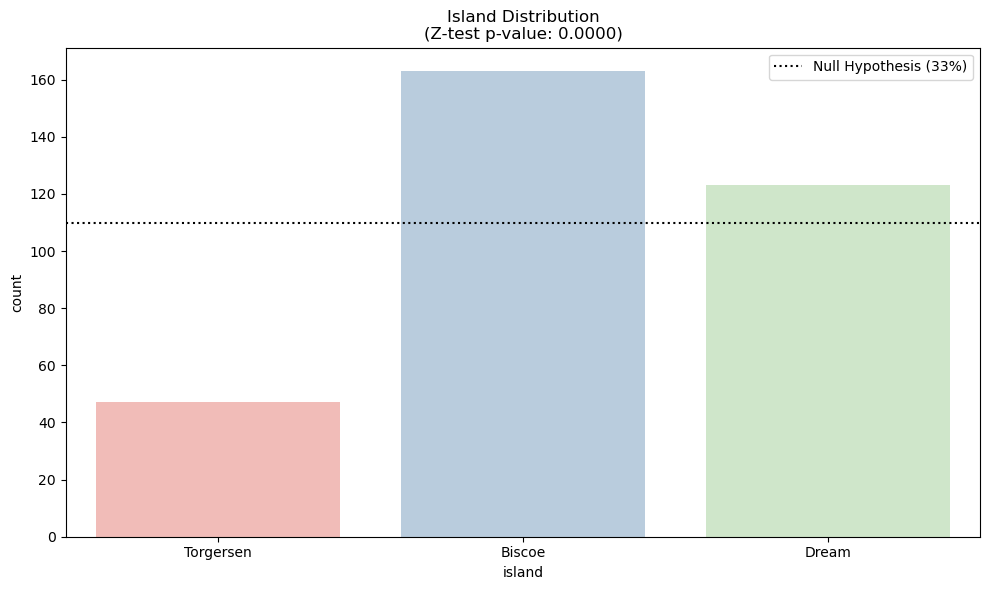

In [14]:
plt.figure(figsize=(10, 6))
sns.countplot(x='island', data=df, palette='Pastel1')
plt.axhline(n_total * 0.33, color='black', linestyle=':', label='Null Hypothesis (33%)')
plt.title(f'Island Distribution\n(Z-test p-value: {z_pval:.4f})')
plt.legend()
plt.tight_layout()
plt.show()

## Task of your choice  

### Hypothesis test of Proportion: Are there equal numbers of male and female penguins on Dream island?

In [36]:
# Null: There are equal numbers of male and female penguins on Dream Islands?
# Alt: There are not equal numbers of male and female penguins on Dream Islands

dream  = df[df['island'] == 'Dream']
count_male = len(dream[dream['sex'] == 'Male'])
count_female = len(dream[dream['sex'] == 'Female'])
n_dream = len(dream)

#null_prop is zero

z_stat, z_pval = proportions_ztest(count=[count_male, count_female], nobs=n_dream, value=0)

print("Z-Test of Proportions ---")
print(f' Male Sample Proportion {count_male/n_dream:.3f}')
print(f' Female Sample Proportion {count_female/n_dream:.3f} \n') 

print(f' Z-statistic: {z_stat:.3f}')
print(f' P-value: {z_pval:.3f}')

if z_pval < 0.05:
    print("Decision: Reject H0")
    print(f"Proportion of Male to Female penguins on Dream island is not equal")
    
else:
    print("Decision: Fail to reject H0")
                                                        

Z-Test of Proportions ---
 Male Sample Proportion 0.504
 Female Sample Proportion 0.496 

 Z-statistic: 0.128
 P-value: 0.899
Decision: Fail to reject H0
